In [2]:
using Colors
using Images, ImageMagick
using FileIO
using Interpolations
using Statistics

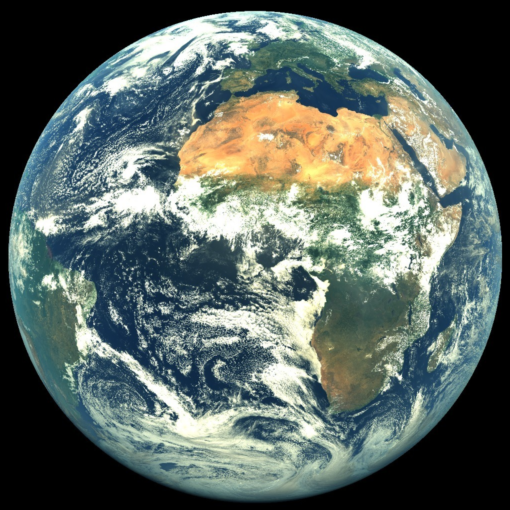

In [3]:
fname = "earth_brick_2025-08-11_2.png"
img = load(fname)

i = 598 .+ (0:1019)
j = 61 .+ (0:1019)

i = 598 .+ (0:1017)
j = 61 .+ (0:1017)

img = img[j,i]

In [241]:
#img = colorview(RGB,channelview(img) .^ 0.8)

In [4]:
a = img[end-100,500]

In [5]:
#img = whitebalance.(img,img[end-100,500],colorant"white")

In [6]:
block = 24
nblocks = 3

3

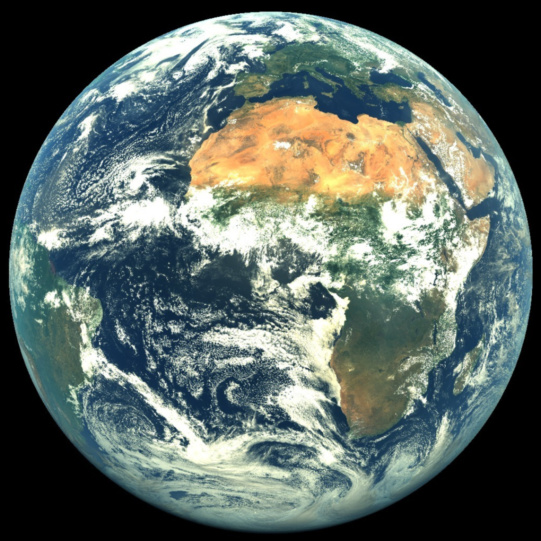

In [7]:
target_size = (block,block) .* nblocks

imgr = imresize(img, cld.(size(img),target_size) .* target_size)

Colors from my filament kit :-)

In [28]:
html_codes =  """
#f291c2
#796fc0
#404ec0
#3da6f0
#3ad429
#ddd219
#f48a29
#e73440
#efd2c9
#d4b69f
#536745
#563229
#6c6b6d
#eae9e6
#000000
"""



color_palette = parse.(Colorant,split(html_codes))

In [29]:
deleteat!(color_palette,13)
deleteat!(color_palette,7)


In [30]:
length(color_palette)

13

In [31]:
?colordiff

search: colordiff colordim colorview color colormap colorsigned color_type



```julia
colordiff(a, b; metric=DE_2000())
```

Compute an approximate measure of the perceptual difference between colors `a` and `b`. Optionally, a `metric` may be supplied, chosen among [`DE_2000`](@ref) (the default), [`DE_94`](@ref), [`DE_JPC79`](@ref), [`DE_CMC`](@ref), [`DE_BFD`](@ref), [`DE_AB`](@ref), [`DE_DIN99`](@ref), [`DE_DIN99d`](@ref) and [`DE_DIN99o`](@ref).

The return value is a non-negative number in a type depending on the colors and metric.

!!! note
    The supported metrics measure the difference within `Lab` or its variant colorspaces. When the input colors are not in the colorspace internally used by the metric, the colors (e.g. in `RGB`) are converted with the default whitepoint CIE D65 (`Colors.WP_D65`). If you want to use another whitepoint, convert the colors into the colorspace used by metric (e.g. `Lab` for [`DE_2000`](@ref)) in advance.



In [32]:
function nearest_color(img,color_palette,black,blue)
    img_index = zeros(UInt8,size(img)) 
    m = size(img) .÷ 2
    for i = axes(img,1)
        for j = axes(img,2)
            #if colordiff(img[i,j],color_palette[14]) < 29
            #    img_index[i,j] = 14
            #else
            
            ii = argmin(colordiff.(img[i,j],color_palette))
            img_index[i,j] = ii
            if (sqrt(sum(((i,j) .- m).^2)) < 0.9*m[1]) && (img_index[i,j] == black)
                img_index[i,j] = blue
            end
            #end
        end
    end
    return img_index
end

img_index = @time nearest_color(imgr,color_palette,length(color_palette),3);

  5.718760 seconds (2.48 M allocations: 133.099 MiB, 7.99% gc time, 2.06% compilation time)


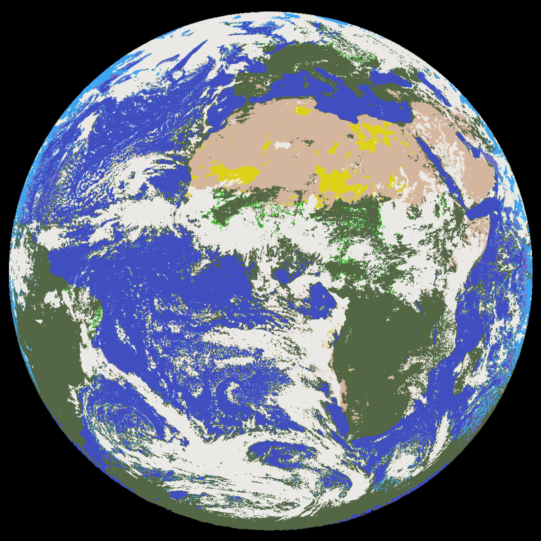

In [33]:
color_palette[img_index]

In [34]:
img2 = reshape(img_index,(size(img_index,1) ÷ target_size[1],target_size[1],size(img_index,2) ÷ target_size[2],target_size[2]));

In [35]:
size(img2),typeof(img2)

((15, 72, 15, 72), Array{UInt8, 4})

In [36]:
img3 = UInt8.(median(reshape(permutedims(img2,(1,3,2,4)),:,target_size...),dims=1)[1,:,:]);

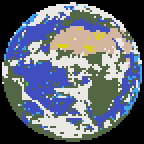

In [37]:

color_palette[img3]

In [38]:
for (i,c) in enumerate(color_palette)
    display(c)
    println(count(==(i),img3))
end


0


2


1038


149


2


40


0


0


364


1185


0


1029


1375


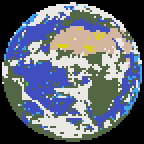

In [39]:
img_final = color_palette[img3]

In [40]:
f = 12

12

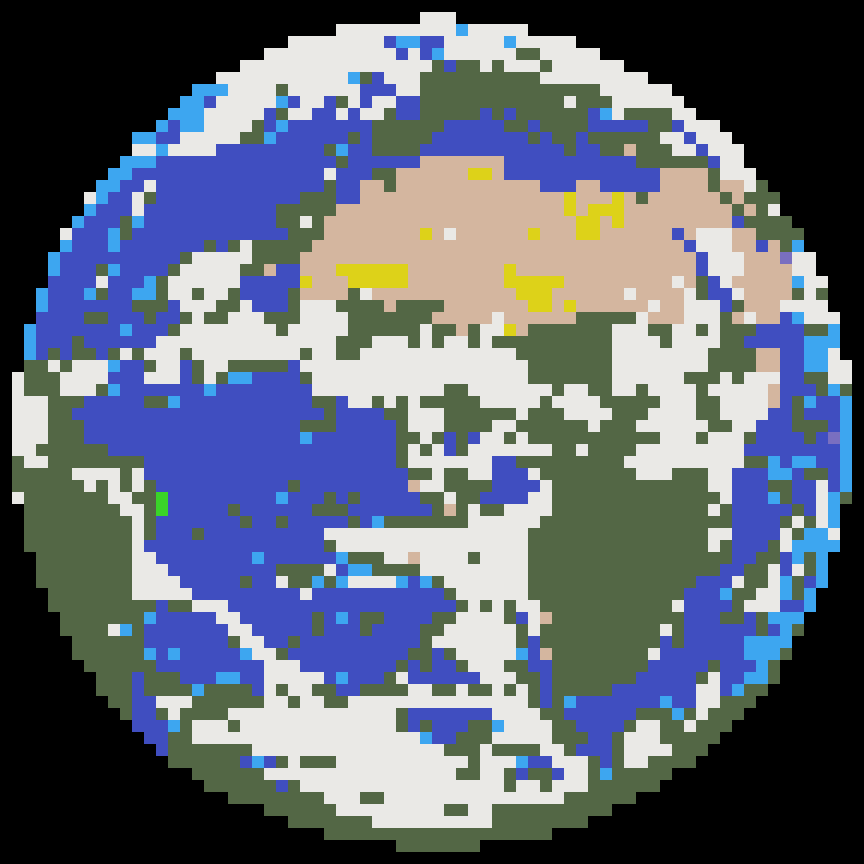

In [41]:
img_final2 = repeat(img_final,inner=(f,f))

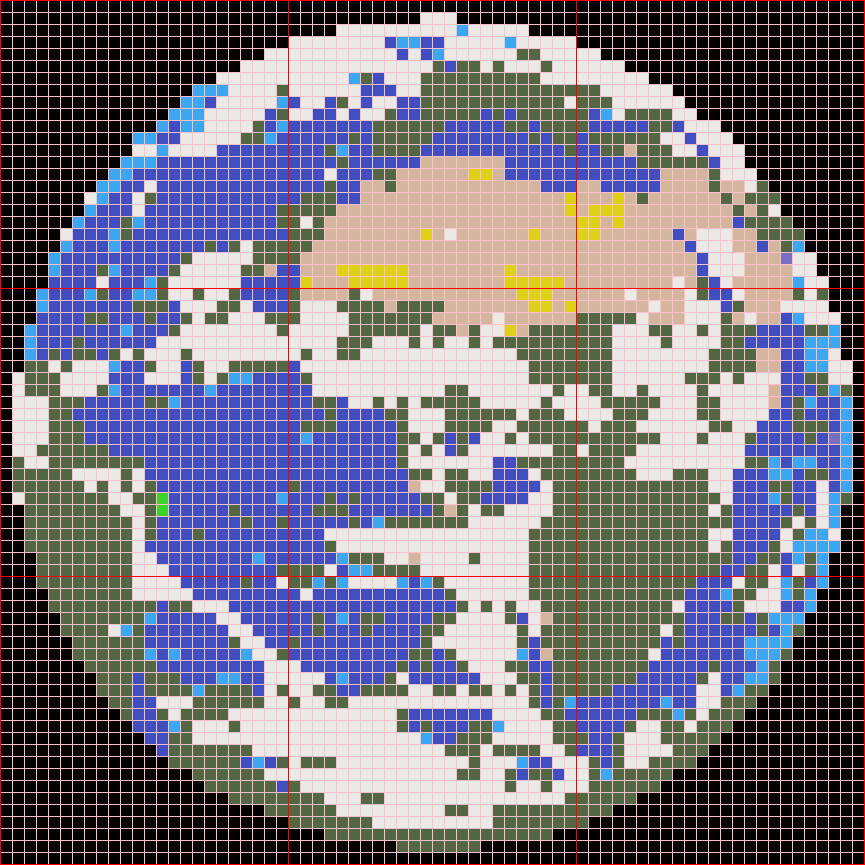

In [42]:
img_final2 = fill(colorant"red",size(img_final) .* f .+ 1)
img_final2[1:end-1,1:end-1] = repeat(img_final,inner=(f,f))

img_final2[1:f:end,:] .= colorant"pink"
img_final2[:,1:f:end] .= colorant"pink"

g = f*block
img_final2[1:g:end,:] .= colorant"red"
img_final2[:,1:g:end] .= colorant"red"

img_final2

In [273]:
save("brick-earth-plan.png",img_final2)

In [276]:
(72/2)^2 * pi

4071.5040790523717